<a href="https://colab.research.google.com/github/rahul-120/iris_flower_type_prediction/blob/main/iris_flower_predic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# iris = load_iris()
df = pd.read_csv("/content/Iris.csv")
# Convert to DataFrame
# df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map numeric target to names
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,species
0,1,5.1,3.5,1.4,0.2,Iris-setosa,setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa,setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa,setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa,setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa,setosa


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
 6   species        150 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 8.3+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.shape

(150, 7)

In [ ]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species', 'species'],
      dtype='object')

## class distribution

In [ ]:
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


## Visualization

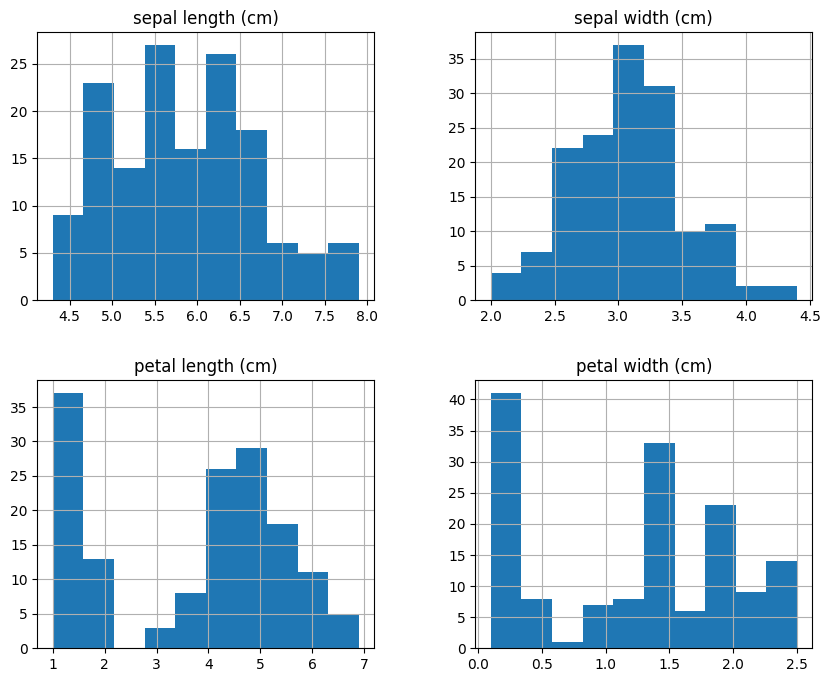

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()

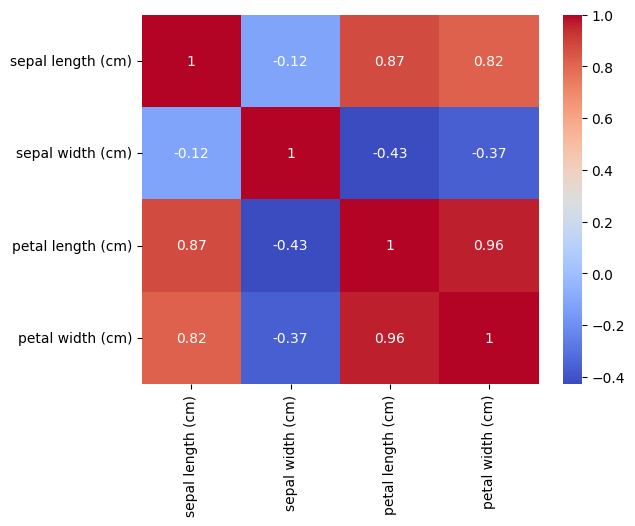

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

## Correlation Analysis

## Split Data (Training + Testing)

In [ ]:
X = df.drop('species', axis=1)   # features
y = df['species']                # target

X_train, X_nbtest, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Model (KNN)

In [ ]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

# Prediction

In [ ]:
y_pred = model.predict(X_test)

# Evaluation

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
import joblib

In [ ]:
# save model
joblib.dump(model, 'iris_knn_model.pkl')

['iris_knn_model.pkl']